# ST1504 Deep Learning — (CA1)
## Part A: Convolutional Neural Network (CNN) for Image Classification

### Name - Thoon Wai Si (2532633)
### Class - DAAA/FT/1B/21

**Dataset:** EMNIST Letters  
**Task:** Classify handwritten letters (A–Z) from 28×28 grayscale images  
**Model:** Custom CNN built from scratch using Keras/TensorFlow


## 1. Imports and Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Set random seeds for reproducibility (following lab convention)
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

TensorFlow version: 2.10.0
GPU available: True


---

## 2. Background Research

### EMNIST (Extended MNIST) Dataset
The EMNIST dataset is derived from the NIST Special Database 19 and converted to match the 28×28 pixel format of MNIST. The **Letters** split contains:
- **26 classes** corresponding to letters A–Z (labels 1–26)
- Each image is a **28×28 grayscale** handwritten character
- Roughly balanced classes (~3,400 samples per class)

### Why CNN for Image Classification?
Convolutional Neural Networks (CNNs) are particularly effective for image tasks because:
1. **Local connectivity**: Convolutional filters detect local patterns (edges, curves) that are translation-invariant
2. **Parameter sharing**: The same filter is applied across the image, drastically reducing parameters vs. a fully-connected network
3. **Hierarchical feature learning**: Early layers detect simple features (edges); deeper layers combine these into complex shapes

A fully connected network operating on flattened pixels does not naturally preserve spatial relationships, whereas CNNs explicitly exploit the spatial structure of images.

---

## 3. Load and Explore the Dataset (EDA)

### 3.1 Load raw CSV and inspect structure

In [4]:
# Load the EMNIST letters CSV
# Format: first column is label (1–26 = A–Z), remaining 784 columns are pixel values
df = pd.read_csv('emnist-letters.csv', header=None)
print(f'Raw dataset shape: {df.shape}')
print(f'Unique labels found: {sorted(df[0].unique())}')

Raw dataset shape: (99040, 785)
Unique labels found: [-2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99040 entries, 0 to 99039
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 593.2 MB


In [8]:
# Check for missing values
missing = df.isnull().sum().sum()
print(f"Missing values    : {missing}")
print(f"Duplicate rows    : {df.duplicated().sum()}")

Missing values    : 0
Duplicate rows    : 9465


9,465 duplicate rows were found. As similar strokes are common in handwriting datasets and duplicates are balanced across classes, they were retained to preserve training data. Future tests may assess their impact on model performance.

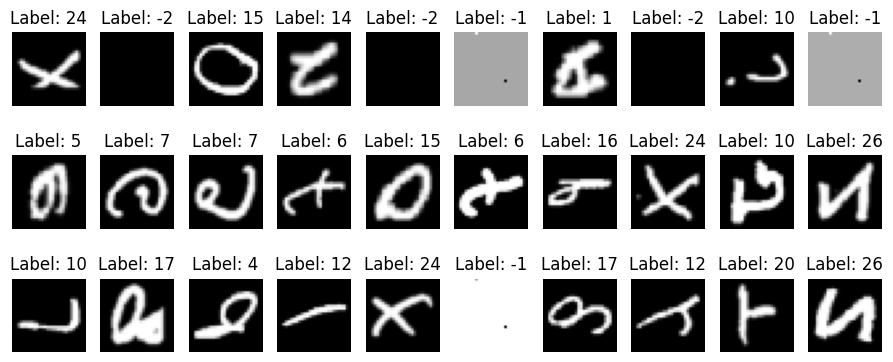

In [3]:
# Overall Image inspection 
labels = df.iloc[:, 0]
valid_sample_indices = df[labels.between(-2, 26)].head(30).index

plt.figure(figsize=(9, 4))

for i, index in enumerate(valid_sample_indices):
    label = df.iloc[index, 0]
    pixels = df.iloc[index, 1:].values
    test_image = pixels.reshape(28, 28)

    plt.subplot(3, 10, i + 1)
    plt.imshow(test_image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The visual inspection shows that labels 1–26 produce recognisable character images, although they are not properly oriented yet. However, labels -1 and -2 mostly contain blank or distorted images instead of valid letters. Since these labels fall outside the expected class range, they may need to be removed before training the CNN.

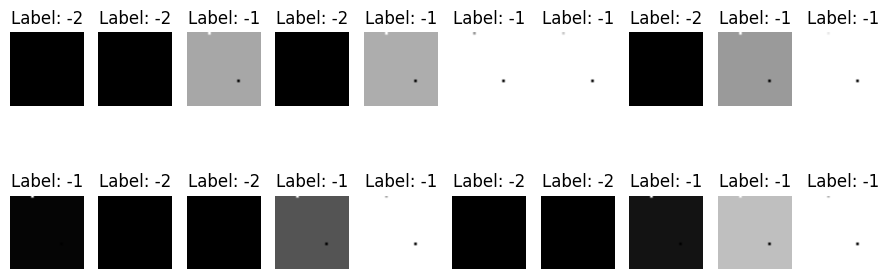

In [4]:
labels = df.iloc[:, 0]
invalid_sample_indices = df[labels.between(-2, -1)].head(20).index

plt.figure(figsize=(9, 4))

for i, index in enumerate(invalid_sample_indices):
    label = df.iloc[index, 0]
    pixels = df.iloc[index, 1:].values
    test_image = pixels.reshape(28, 28)

    plt.subplot(2, 10, i + 1)
    plt.imshow(test_image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Rows labelled -1 and -2 do not contain meaningful letter shapes and mostly appear as blank, flat-coloured, or noisy images. Removing them is justified because they are invalid samples that would add noise to the 26-letter classification task.

In [5]:
# Remove rows with invalid labels (-1, -2 are corrupt/noise rows)
# These rows contain uniform pixel values (142 or 131), indicating padding/noise
df_clean = df[df[0] > 0].reset_index(drop=True)
print(f'Rows removed (noise): {len(df) - len(df_clean)}')
print(f'Clean dataset shape: {df_clean.shape}')

Rows removed (noise): 10240
Clean dataset shape: (88800, 785)


### 3.2 Class Distribution

We count how many samples exist for each letter class (A–Z) to check for class imbalance.

**Why this matters:** An imbalanced dataset — where some classes have far more samples than others — can cause the model to be biased toward predicting the majority class. Before training, we must verify the dataset is balanced.

**Method:**
- `value_counts()` counts samples per label; `sort_index()` orders them A–Z
- `chr(64 + i)` converts numeric labels (1–26) to letter characters (A–Z) using ASCII codes
- A horizontal red dashed line marks the mean sample count across all classes

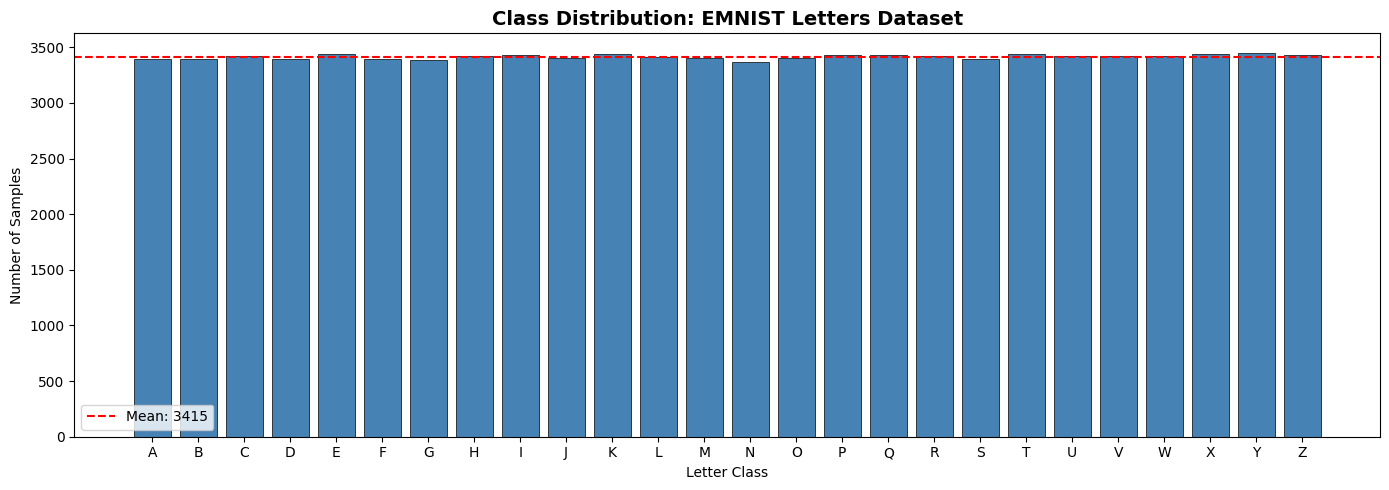

Min samples pSer class: 3365 (N)
Max samples per class: 3453 (Y)
Std deviation: 20.3 — dataset is well balanced


In [6]:
# Class distribution
label_counts = df_clean[0].value_counts().sort_index()
letter_names = [chr(64 + i) for i in range(1, 27)]  # A=1, B=2, ..., Z=26

plt.figure(figsize=(14, 5))
bars = plt.bar(letter_names, label_counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Class Distribution: EMNIST Letters Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Letter Class')
plt.ylabel('Number of Samples')
plt.axhline(y=label_counts.mean(), color='red', linestyle='--', label=f'Mean: {label_counts.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f'Min samples pSer class: {label_counts.min()} ({letter_names[label_counts.idxmin()-1]})')
print(f'Max samples per class: {label_counts.max()} ({letter_names[label_counts.idxmax()-1]})')
print(f'Std deviation: {label_counts.std():.1f} — dataset is well balanced')

The class distribution analysis reveals that the dataset is well balanced, with each of the 26 letter classes containing between 3,365 and 3,453 samples (std = 20.3). This eliminates the need for class weighting or oversampling techniques such as SMOTE prior to training.

### 3.3 Pixel Statistics

Before preprocessing, we examine the raw pixel value range across the entire dataset.

**Why this matters:** Knowing the pixel range determines how we should normalise the data. Neural networks train poorly on large raw values — normalising to [0, 1] stabilises gradients and speeds up convergence.


In [21]:
# Pixel statistics
pixels = df_clean.iloc[:, 1:].values
print(f'Pixel value range: {pixels.min()} – {pixels.max()}')
print(f'Mean pixel value: {pixels.mean():.2f}')
print(f'Std of pixel values: {pixels.std():.2f}')
print(f'\nNote: Pixel values range from 0 to 255, consistent with standard grayscale images.')
print(f'We normalise by dividing by 255 to scale all values to [0, 1] before training.')

Pixel value range: 0 – 255
Mean pixel value: 43.92
Std of pixel values: 84.40

Note: Pixel values range from 0 to 255, consistent with standard grayscale images.
We normalise by dividing by 255 to scale all values to [0, 1] before training.


### 3.4 Sample Image Visualisation
We display one sample image per letter class (A–Z) to visually inspect the data before training.

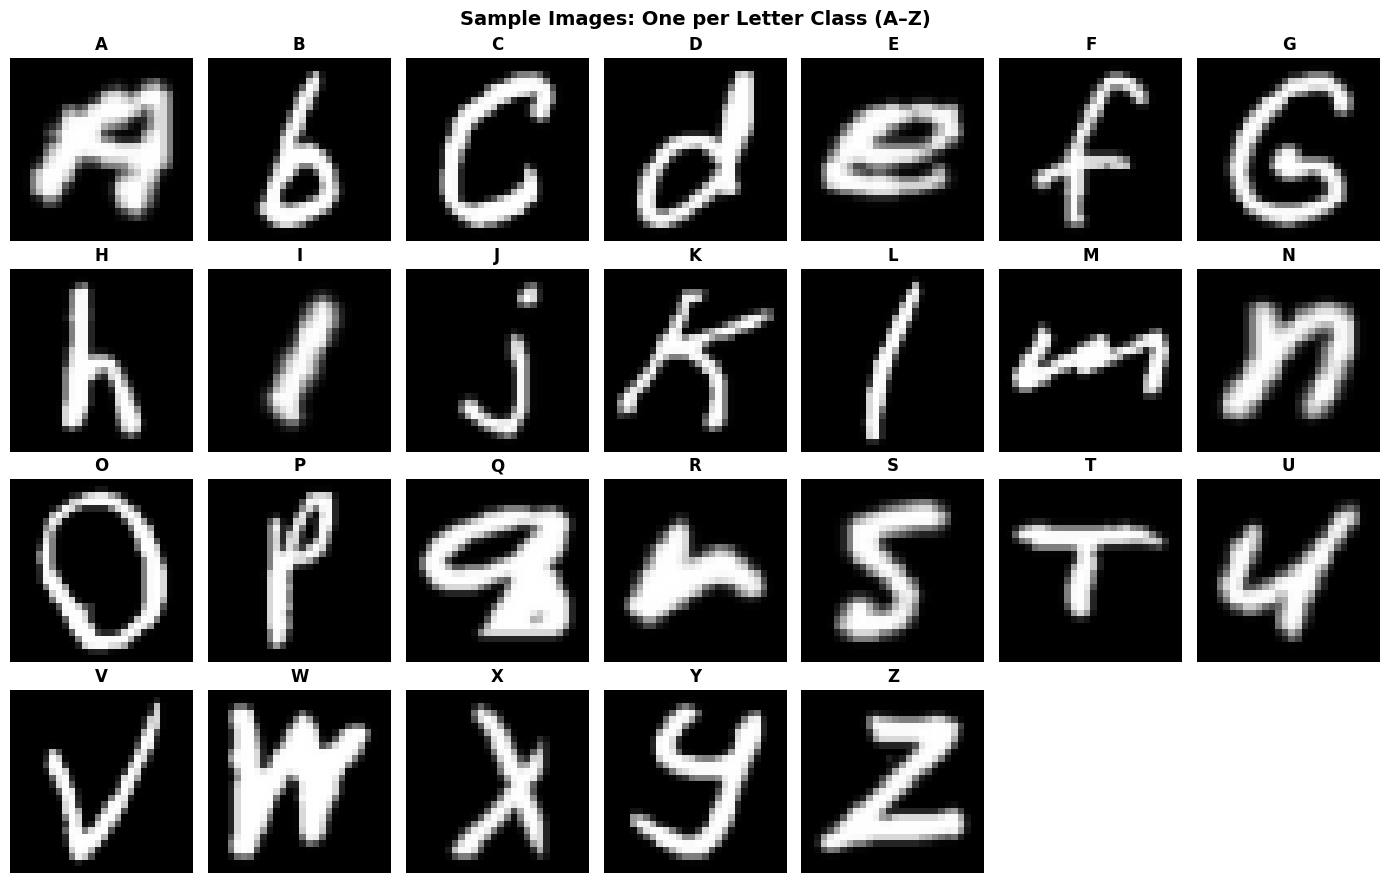

In [22]:
# Visualise sample images from each class
# EMNIST letters are stored transposed — we flip them back
fig, axes = plt.subplots(4, 7, figsize=(14, 9))
axes = axes.flatten()

for idx, letter_label in enumerate(range(1, 27)):
    sample = df_clean[df_clean[0] == letter_label].iloc[0, 1:].values
    img = sample.reshape(28, 28).T  # Transpose to correct EMNIST orientation
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{chr(64 + letter_label)}', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide the last 2 unused subplots
axes[26].axis('off')
axes[27].axis('off')

plt.suptitle('Sample Images: One per Letter Class (A–Z)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

**Key implementation notes:**
- Images in the EMNIST CSV are stored as a flat array of 784 values — we reshape each to (28, 28) before displaying
- EMNIST letter images are stored transposed in the CSV, so `.T` (transpose) is applied to restore correct orientation
- A 4×7 subplot grid provides 28 slots for 26 letters; the 2 unused slots are hidden with `axis('off')`

**Observation:** The images are clearly legible handwritten letters. Visible variation in stroke angle, thickness, and style across samples motivates the use of data augmentation during training to improve model robustness.

### 3.5 Intra-class Variation Analysis

To further understand the data, I plot 50 samples of the letter 'A' to observe how much variation exists within a single class.

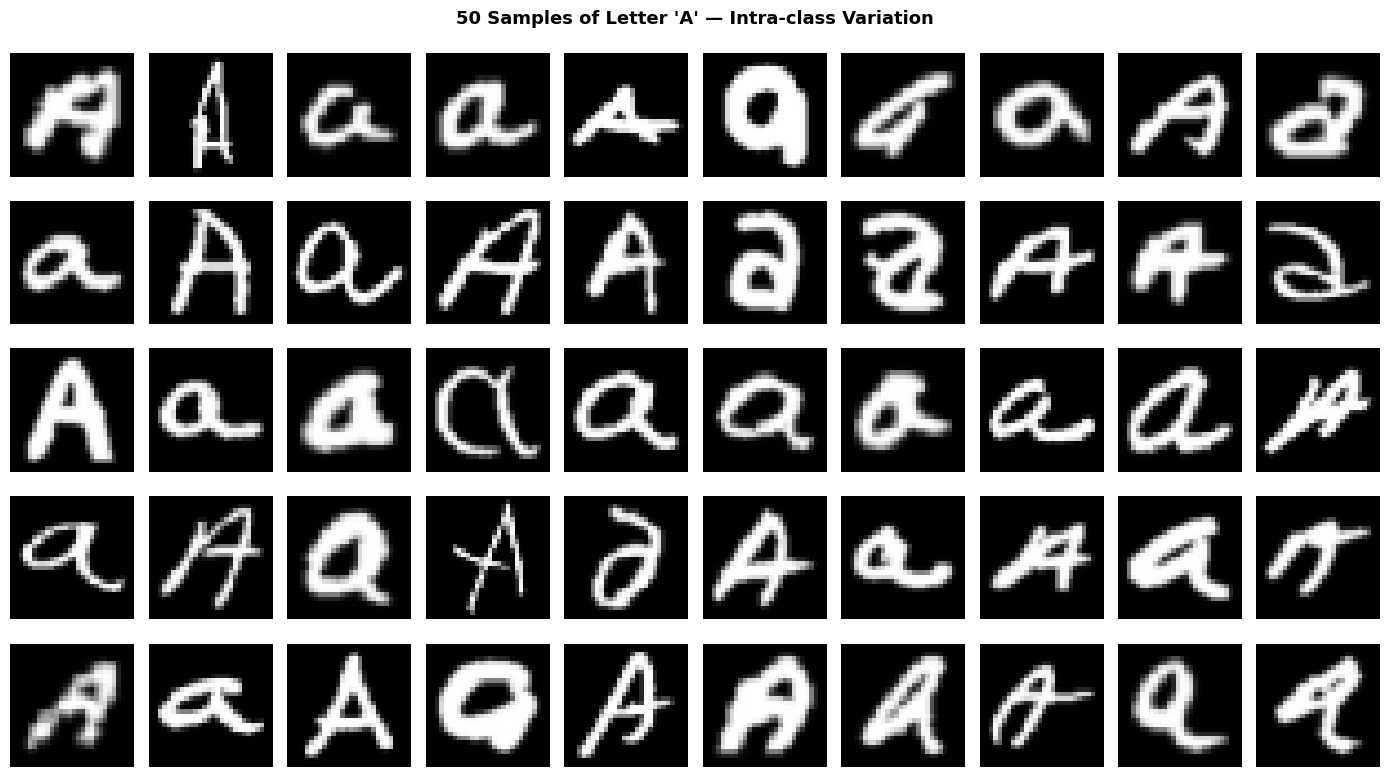

Observation: There is significant variation in stroke width, angle, and style.
This suggests data augmentation (rotation, shifting) could be beneficial.


In [7]:
# Show multiple samples per class to understand intra-class variation
fig, axes = plt.subplots(5, 10, figsize=(14, 8))
sample_letter = 1  # Letter 'A'
samples_A = df_clean[df_clean[0] == sample_letter].head(50)

for i, (_, row) in enumerate(samples_A.iterrows()):
    img = row[1:].values.reshape(28, 28).T
    axes[i // 10][i % 10].imshow(img, cmap='gray')
    axes[i // 10][i % 10].axis('off')

plt.suptitle("50 Samples of Letter 'A' — Intra-class Variation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('intra_class_variation.png', dpi=150)
plt.show()
print('Observation: There is significant variation in stroke width, angle, and style.')
print('This suggests data augmentation (rotation, shifting) could be beneficial.')

**Key implementation notes:**
- `iterrows()` loops through each sample row by row
- `i // 10` and `i % 10` map a flat counter to a 2D grid position (row, column)
- `.reshape(28, 28).T` restores correct image orientation (EMNIST-specific transpose)

**Observation:** Even within a single class, there is significant variation in stroke width, letter size, tilt angle, and writing style. Some samples show uppercase 'A' while others show lowercase 'a'.

**Implication for modelling:** This intra-class variation motivates the use of data augmentation techniques such as rotation and shifting during training. By exposing the model to artificially varied samples, we improve its ability to generalise to unseen handwriting styles.

### 3.6 Pixel Intensity Distribution

Beyond summary statistics (min, max, mean), it is useful to visualise the **full distribution** of pixel values across the dataset.

**Why this matters:**
- Most pixels in handwritten letter images are background (value = 0 or close to 0)
- Only a small fraction of pixels represent the actual letter strokes (high values)
- This tells us the data is **sparse** — dominated by black background pixels
- Understanding this distribution confirms that normalisation is necessary before training, as raw pixel values would cause gradient instability in the network

**What to look for:** A large spike near 0 (background pixels) and a smaller distribution of higher values (stroke pixels).

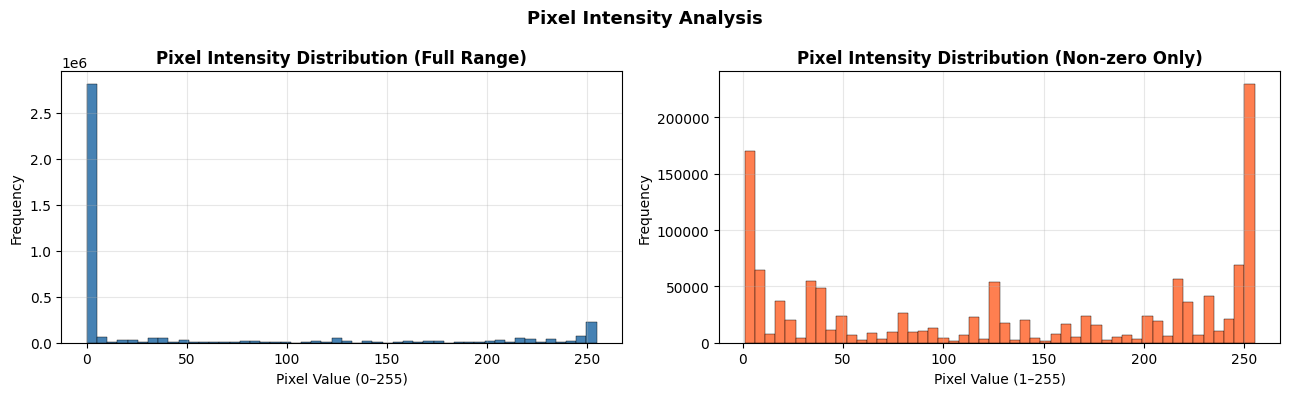

Percentage of zero (background) pixels: 67.4%
Percentage of non-zero (stroke) pixels: 32.6%

Conclusion: The dataset is highly sparse — most pixels are background.
Normalising to [0, 1] is essential to prevent large raw values from destabilising training.


In [24]:
# Pixel Intensity Histogram
# Sample 5000 rows for speed — avoids plotting 88k * 784 = 69M values
sample_pixels = df_clean.iloc[:5000, 1:].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Full distribution (all pixel values)
axes[0].hist(sample_pixels, bins=50, color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('Pixel Intensity Distribution (Full Range)', fontweight='bold')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Right: Non-zero pixels only — shows stroke intensity distribution
nonzero_pixels = sample_pixels[sample_pixels > 0]
axes[1].hist(nonzero_pixels, bins=50, color='coral', edgecolor='black', linewidth=0.3)
axes[1].set_title('Pixel Intensity Distribution (Non-zero Only)', fontweight='bold')
axes[1].set_xlabel('Pixel Value (1–255)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pixel Intensity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_histogram.png', dpi=150)
plt.show()

zero_pct = (sample_pixels == 0).sum() / len(sample_pixels) * 100
print(f'Percentage of zero (background) pixels: {zero_pct:.1f}%')
print(f'Percentage of non-zero (stroke) pixels: {100 - zero_pct:.1f}%')
print(f'\nConclusion: The dataset is highly sparse — most pixels are background.')
print(f'Normalising to [0, 1] is essential to prevent large raw values from destabilising training.')

---
## 4. Data Preprocessing

### 4.1 I applied four steps before training:

- **Extract**: Pixel columns (1–784) separated from label column (0); cast to `float32`
- **Normalise**: Divide by 255 → scales pixels to [0, 1], stabilises gradient descent
- **Re-index labels**: Subtract 1 from labels (1–26 → 0–25) as Keras requires 0-indexed classes
- **Reshape**: Flatten array → (28, 28) → transpose `.T` to fix EMNIST orientation → add channel dimension → final shape (28, 28, 1) for CNN input

In [25]:
# Extract features and labels
X = df_clean.iloc[:, 1:].values.astype('float32')  # 784 pixel values
y = df_clean.iloc[:, 0].values                      # Labels 1–26

# Normalise pixel values to [0, 1]
# Justification: Normalisation speeds up training and prevents gradient issues.
X = X / 255.0

# Convert labels to 0-indexed (A=0, B=1, ..., Z=25)
y = y - 1
NUM_CLASSES = 26

# Reshape to (samples, 28, 28, 1) — CNN expects (height, width, channels)
# Transpose each image to fix EMNIST orientation
X = X.reshape(-1, 28, 28)
X = np.array([img.T for img in X])  # Correct orientation
X = X.reshape(-1, 28, 28, 1)        # Add channel dimension

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Pixel range after normalisation: {X.min():.3f} – {X.max():.3f}')
print(f'Label range: {y.min()} – {y.max()} (0=A, 25=Z)')

X shape: (88800, 28, 28, 1)
y shape: (88800,)
Pixel range after normalisation: 0.000 – 1.000
Label range: 0 – 25 (0=A, 25=Z)


### 4.2 Train / Validation / Test Split

The dataset is split into 70% train, 15% validation, and 15% test sets.

- **70% train (62,160 samples)**: Used to update model weights during training
- **15% val (13,320 samples)**: Monitors performance each epoch to detect overfitting
- **15% test (13,320 samples)**: Final unseen evaluation — only used after training is complete

**`stratify=y`** ensures each letter class is proportionally represented across all three splits — important for fair and unbiased evaluation.

**One-hot encoding** converts integer labels (0–25) into binary vectors of length 26, required by `categorical_crossentropy` loss.

In [26]:
# Train / Validation / Test split: 70% / 15% / 15%
# Justification: With ~88k samples, 15% gives ~13k for val and test each — sufficient for reliable evaluation.
# Stratified split ensures each class is equally represented in all splits.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Training set:   {X_train.shape[0]:>6} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation set: {X_val.shape[0]:>6} samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:       {X_test.shape[0]:>6} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# One-hot encode labels for categorical cross-entropy loss
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

Training set:    62160 samples (70%)
Validation set:  13320 samples (15%)
Test set:        13320 samples (15%)


---
## 5. Baseline CNN Model

### 5.1 Architecture Justification
The baseline model follows a classic CNN pattern:
- **Conv → Pool → Conv → Pool → Flatten → Dense → Output**
- Starting with small filters (3×3) to capture fine-grained features in 28×28 images
- MaxPooling reduces spatial dimensions, making the model robust to small translations
- Filters double each layer (32 → 64) to build increasingly complex representations
- Final Dense layer with Softmax outputs a probability distribution over 26 classes

I used two conv blocks instead of one (as in Lab 3) to better handle the 26-class complexity of letter recognition vs. digit recognition.


In [27]:
def build_baseline_cnn():
    model = models.Sequential([
        # Block 1: Detect low-level features (edges, strokes)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        # Block 2: Detect mid-level features (curves, letter parts)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and classify
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')  # 26 classes
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 3136)              0         
                                                                 
 dense_4 (Dense)             (None, 128)              

In [29]:
# Save best weights during training
checkpoint_baseline = ModelCheckpoint(
    'best_baseline_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
print('Training baseline CNN...')
history_baseline = baseline_model.fit(
    X_train, y_train_oh,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val_oh),
    callbacks=[checkpoint_baseline, early_stop],
    verbose=1
)

Training baseline CNN...
Epoch 1/20
486/486 [==============================] - ETA: 0s - loss: 0.7032 - accuracy: 0.7867
Epoch 1: val_accuracy improved from -inf to 0.88506, saving model to best_baseline_weights.h5
486/486 [==============================] - 31s 20ms/step - loss: 0.7032 - accuracy: 0.7867 - val_loss: 0.3684 - val_accuracy: 0.8851
Epoch 2/20
484/486 [============================>.] - ETA: 0s - loss: 0.3185 - accuracy: 0.8967
Epoch 2: val_accuracy improved from 0.88506 to 0.90999, saving model to best_baseline_weights.h5
486/486 [==============================] - 9s 18ms/step - loss: 0.3189 - accuracy: 0.8967 - val_loss: 0.2908 - val_accuracy: 0.9100
Epoch 3/20
485/486 [============================>.] - ETA: 0s - loss: 0.2530 - accuracy: 0.9162
Epoch 3: val_accuracy improved from 0.90999 to 0.91171, saving model to best_baseline_weights.h5
486/486 [==============================] - 6s 13ms/step - loss: 0.2530 - accuracy: 0.9162 - val_loss: 0.2788 - val_accuracy: 0.9117
Ep

### Training Callbacks
- **ModelCheckpoint**: Saves weights only when `val_accuracy` improves — ensures best weights are always kept
- **EarlyStopping** (patience=5): Stops training if val_accuracy does not improve for 5 consecutive epochs, then restores best weights

### Training Observations
- Best val_accuracy: **92.77%** achieved at epoch 10
- Early stopping triggered at epoch 15
- From epoch 10 onwards, training accuracy continued rising (97%) while val_accuracy plateaued (92%) — indicating **overfitting**
- This gap motivates the use of Dropout and BatchNormalization in the improved model


### 5.2 Training Curve Analysis

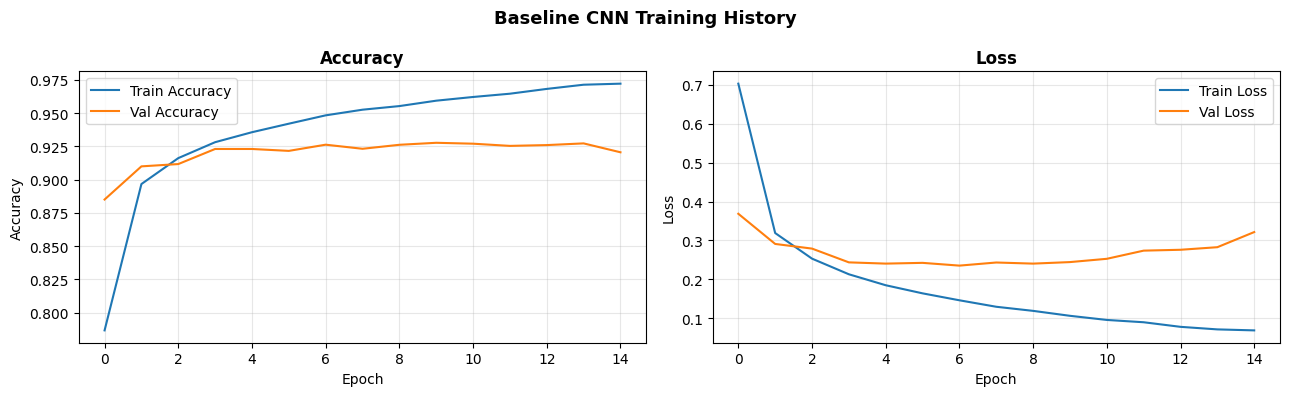

In [30]:
def plot_history(history, title='Model Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN Training History')

**Accuracy (left):** Both train and val accuracy rise together in early epochs. After epoch 6, train accuracy continues climbing to ~97% while val accuracy plateaus at ~93%, revealing a growing gap — a clear sign of overfitting.

**Loss (right):** Train loss drops steadily throughout all epochs. Val loss decreases initially but begins rising after epoch 3, forming a U-shape — the classic overfitting pattern.

**Conclusion:** The baseline model overfits after epoch 10. It memorises training data rather than generalising to unseen samples. This justifies the improvements in the next model: Dropout, BatchNormalization, and data augmentation to close the train/val gap.

### 5.3 Test Set Evaluation

The best saved weights (epoch 10) are loaded before evaluating on the test set — 13,320 images never seen during training or validation.

| Metric | Value |
|---|---|
| Test Accuracy | 92.67% |
| Test Loss | 0.2490 |
| Error Rate | 7.33% |


In [31]:
# Evaluate baseline on test set
baseline_model.load_weights('best_baseline_weights.h5')
test_loss, test_acc = baseline_model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Baseline CNN — Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Baseline CNN — Test Loss:     {test_loss:.4f}')
print('Baseline CNN Error: %.2f%%' % (100 - test_acc * 100))

Baseline CNN — Test Accuracy: 0.9267 (92.67%)
Baseline CNN — Test Loss:     0.2490
Baseline CNN Error: 7.33%


**Observations:**
- Val accuracy (92.77%) and test accuracy (92.67%) differ by only 0.1% — confirming the model generalises consistently to unseen data
- 92.67% is a strong baseline given the task involves 26 visually similar letter classes
- However, the overfitting observed in training curves suggests room for improvement with regularisation techniques

### 5.4 Confusion Matrix and Classification Report

The confusion matrix shows correct predictions on the diagonal (dark blue) and misclassifications off-diagonal.

417/417 [==============================] - 3s 6ms/step


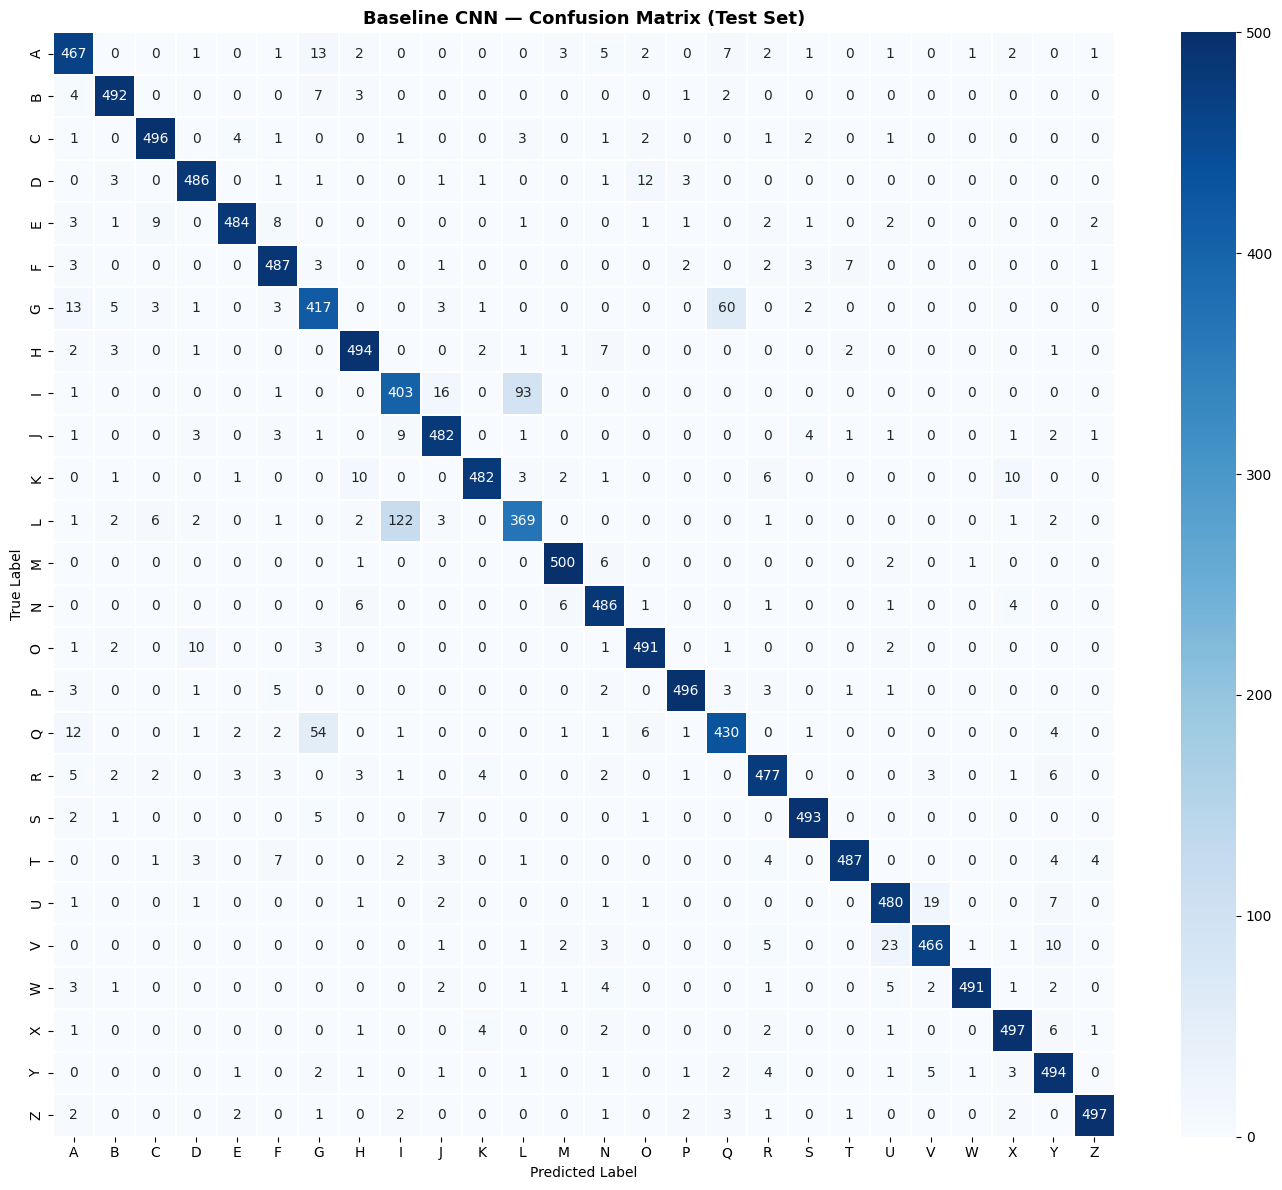


Classification Report:
              precision    recall  f1-score   support

           A       0.89      0.92      0.90       509
           B       0.96      0.97      0.96       509
           C       0.96      0.97      0.96       513
           D       0.95      0.95      0.95       509
           E       0.97      0.94      0.96       515
           F       0.93      0.96      0.94       509
           G       0.82      0.82      0.82       508
           H       0.94      0.96      0.95       514
           I       0.74      0.78      0.76       514
           J       0.92      0.95      0.93       510
           K       0.98      0.93      0.95       516
           L       0.78      0.72      0.75       512
           M       0.97      0.98      0.97       510
           N       0.93      0.96      0.94       505
           O       0.95      0.96      0.96       511
           P       0.98      0.96      0.97       515
           Q       0.85      0.83      0.84       516
   

In [32]:
# Confusion Matrix for baseline
y_pred_baseline = np.argmax(baseline_model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'),
            yticklabels=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'),
            linewidths=0.3)
plt.title('Baseline CNN — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_baseline, target_names=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')))

**Key misclassifications:**
- **I → L (93 times), L → I (122 times)**: Both are thin vertical strokes — visually very similar in handwriting
- **G ↔ Q (60/54 times)**: Both share a curved circular shape
- **I ↔ J**: Similar thin vertical strokes with a small curve

**Weakest classes** (lowest F1-score):
- L: 0.75, I: 0.76 — frequently confused with each other
- G: 0.82, Q: 0.84 — frequently confused with each other

**Strongest classes** (highest F1-score):
- M, W, S, Z: 0.97 — distinctive shapes rarely confused

**Overall accuracy: 92.67%** — strong baseline, but misclassifications on visually similar letters highlight the need for a stronger model.

--------------------------------------------------------------------------------------------------

## 6. Analysis of Baseline Model

The baseline CNN achieved **92.67% test accuracy** — a strong result, but with clear room for improvement.

**Key weaknesses identified:**

- **Overfitting**: Training accuracy (97%) significantly exceeded val accuracy (93%), with val loss rising after epoch 3 — the model memorises rather than generalises
- **I / L confusion**: 93 I's predicted as L, and 122 L's predicted as I — both are thin vertical strokes, making them hard to distinguish
- **G / Q confusion**: 60 G's predicted as Q and 54 Q's predicted as G — both share a circular curved shape
- **Lowest F1-scores**: L (0.75), I (0.76), G (0.82) — all visually ambiguous letters

**How the improved model addresses these:**
- **Dropout + BatchNormalization** → reduces overfitting
- **Deeper architecture (3 conv blocks)** → learns finer distinctions between similar letters
- **Data augmentation** → exposes model to more writing style variations

--------------------------------------------------------------------------------------------------

## 7. Data Augmentation

### Justification
From the intra-class variation visualisation earlier, handwritten letters appear at varied angles, offsets, and scales. Data augmentation artificially increases training diversity by applying small random transformations, making the model more robust.

Augmentations chosen:
- **Rotation (±10°)**: Handwriting is often slightly tilted
- **Width/Height shift (10%)**: Letters may not be perfectly centred
- **Zoom (10%)**: Stroke sizes vary between writers
- **No horizontal flip**: Letters like 'b/d' or 'p/q' are mirror images — flipping would create false training signal

We will verify augmentation is beneficial by comparing validation accuracy with and without it.

### 7.1 Augmentation Visualisation

We visualise 15 augmented versions of one sample to verify transformations look realistic before applying to full training.

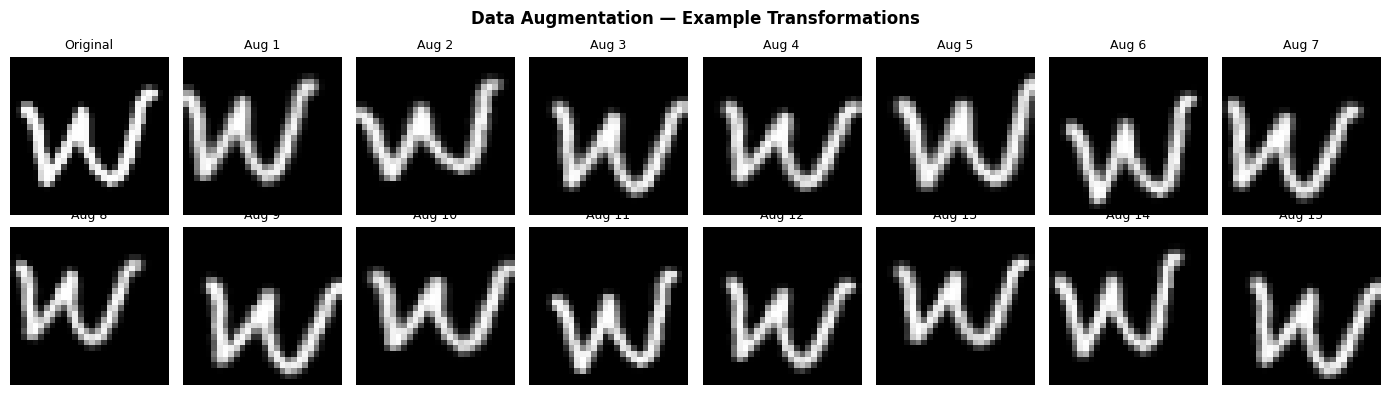

In [33]:
# Visualise augmented samples to confirm they look realistic
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=False  # Important: do NOT flip letters
)

sample_img = X_train[0:1]  # Take one image
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
axes[0][0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0][0].set_title('Original', fontsize=9)
axes[0][0].axis('off')

aug_iter = datagen.flow(sample_img, batch_size=1)
for i in range(1, 16):
    aug_img = next(aug_iter)[0, :, :, 0]
    row, col = divmod(i, 8)
    axes[row][col].imshow(aug_img, cmap='gray')
    axes[row][col].set_title(f'Aug {i}', fontsize=9)
    axes[row][col].axis('off')

plt.suptitle('Data Augmentation — Example Transformations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150)
plt.show()

**Observation:** Each augmented image shows slight variation in rotation, position, and size — all still clearly recognisable as the same letter. This confirms the augmentation parameters are appropriate — realistic enough to add diversity without distorting the letter beyond recognition.

The augmented images are generated on-the-fly during training using `datagen.flow()`, meaning no new files are created — the model simply sees a differently transformed version of each image every epoch.

--------------------------------------------------------------------------------------------------

## 8. Improved CNN Model

### Improvements Made

Based on the weaknesses identified in Section 6, the following improvements are applied:

1. **Deeper architecture (3 conv blocks, 64→128→256 filters)**: Baseline confused similar letters (I/L, G/Q) — more blocks learn finer distinctions between visually similar shapes
2. **Batch Normalisation**: Normalises activations between layers, stabilising and accelerating training
3. **Dropout (0.25 conv, 0.5 dense)**: Baseline overfitted (train 97% vs val 93%) — dropout randomly disables neurons during training to force better generalisation
4. **Data Augmentation**: Increases training diversity by applying random rotations, shifts and zoom each epoch
5. **ReduceLROnPlateau**: Automatically halves the learning rate when val_accuracy stops improving — allows fine-tuning near convergence

In [35]:
def build_improved_cnn():
    model = models.Sequential([
        # Block 1: Low-level features
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2: Mid-level features
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3: High-level features
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),  # Higher dropout in dense layer to prevent overfitting
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

improved_model = build_improved_cnn()
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
improved_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 28, 28, 64)        640       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 64)       256       
 ormalization)                                                   
                                                                 
 conv2d_7 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                      

### 8.1 Model Summary

The improved model has **1,752,282 total parameters** — 4× more than the baseline (423,706), giving it significantly more capacity to learn complex letter features.

**Architecture progression:**
- Block 1: Conv(64) → BN → Conv(64) → BN → Pool → Dropout(0.25)
- Block 2: Conv(128) → BN → Conv(128) → BN → Pool → Dropout(0.25)
- Block 3: Conv(256) → BN → Pool → Dropout(0.25)
- Head: Flatten → Dense(512) → BN → Dropout(0.5) → Dense(26)

**Note:** 2,304 non-trainable params belong to BatchNormalization layers — these track running mean and variance during training but are not updated by backpropagation.

**Dropout(0.5)** is higher in the Dense layer than in conv blocks (0.25) because dense layers have far more parameters and are more prone to overfitting.

In [36]:
checkpoint_improved = ModelCheckpoint(
    'best_improved_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_improved = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when val_accuracy stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Use augmented data generator for training
train_generator = datagen.flow(X_train, y_train_oh, batch_size=128)
steps_per_epoch = len(X_train) // 128

print('Training improved CNN with data augmentation...')
history_improved = improved_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=(X_val, y_val_oh),
    callbacks=[checkpoint_improved, early_stop_improved, reduce_lr],
    verbose=1
)

Training improved CNN with data augmentation...
Epoch 1/30
485/485 [==============================] - ETA: 0s - loss: 0.8219 - accuracy: 0.7552
Epoch 1: val_accuracy improved from -inf to 0.60773, saving model to best_improved_weights.h5
485/485 [==============================] - 61s 112ms/step - loss: 0.8219 - accuracy: 0.7552 - val_loss: 1.3100 - val_accuracy: 0.6077 - lr: 0.0010
Epoch 2/30
484/485 [============================>.] - ETA: 0s - loss: 0.3482 - accuracy: 0.8843
Epoch 2: val_accuracy improved from 0.60773 to 0.93003, saving model to best_improved_weights.h5
485/485 [==============================] - 49s 100ms/step - loss: 0.3482 - accuracy: 0.8843 - val_loss: 0.2047 - val_accuracy: 0.9300 - lr: 0.0010
Epoch 3/30
485/485 [==============================] - ETA: 0s - loss: 0.2836 - accuracy: 0.9055
Epoch 3: val_accuracy improved from 0.93003 to 0.93994, saving model to best_improved_weights.h5
485/485 [==============================] - 45s 92ms/step - loss: 0.2836 - accuracy

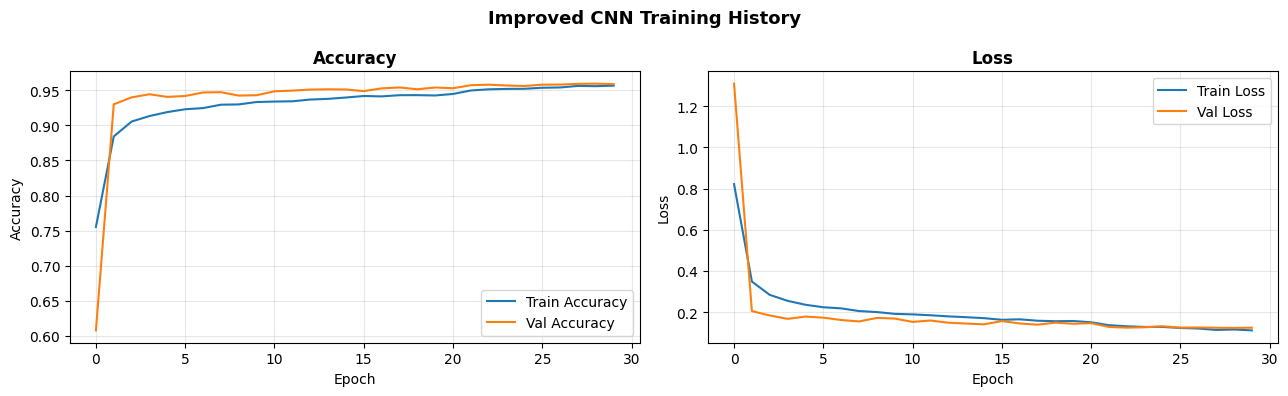

In [37]:
plot_history(history_improved, 'Improved CNN Training History')

In [38]:
# Evaluate improved model on test set
improved_model.load_weights('best_improved_weights.h5')
test_loss_imp, test_acc_imp = improved_model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Improved CNN — Test Accuracy: {test_acc_imp:.4f} ({test_acc_imp*100:.2f}%)')
print(f'Improved CNN — Test Loss:     {test_loss_imp:.4f}')
print('Improved CNN Error: %.2f%%' % (100 - test_acc_imp * 100))
print(f'\nImprovement over baseline: +{(test_acc_imp - test_acc)*100:.2f}%')

Improved CNN — Test Accuracy: 0.9567 (95.67%)
Improved CNN — Test Loss:     0.1230
Improved CNN Error: 4.33%

Improvement over baseline: +3.00%


417/417 [==============================] - 3s 7ms/step


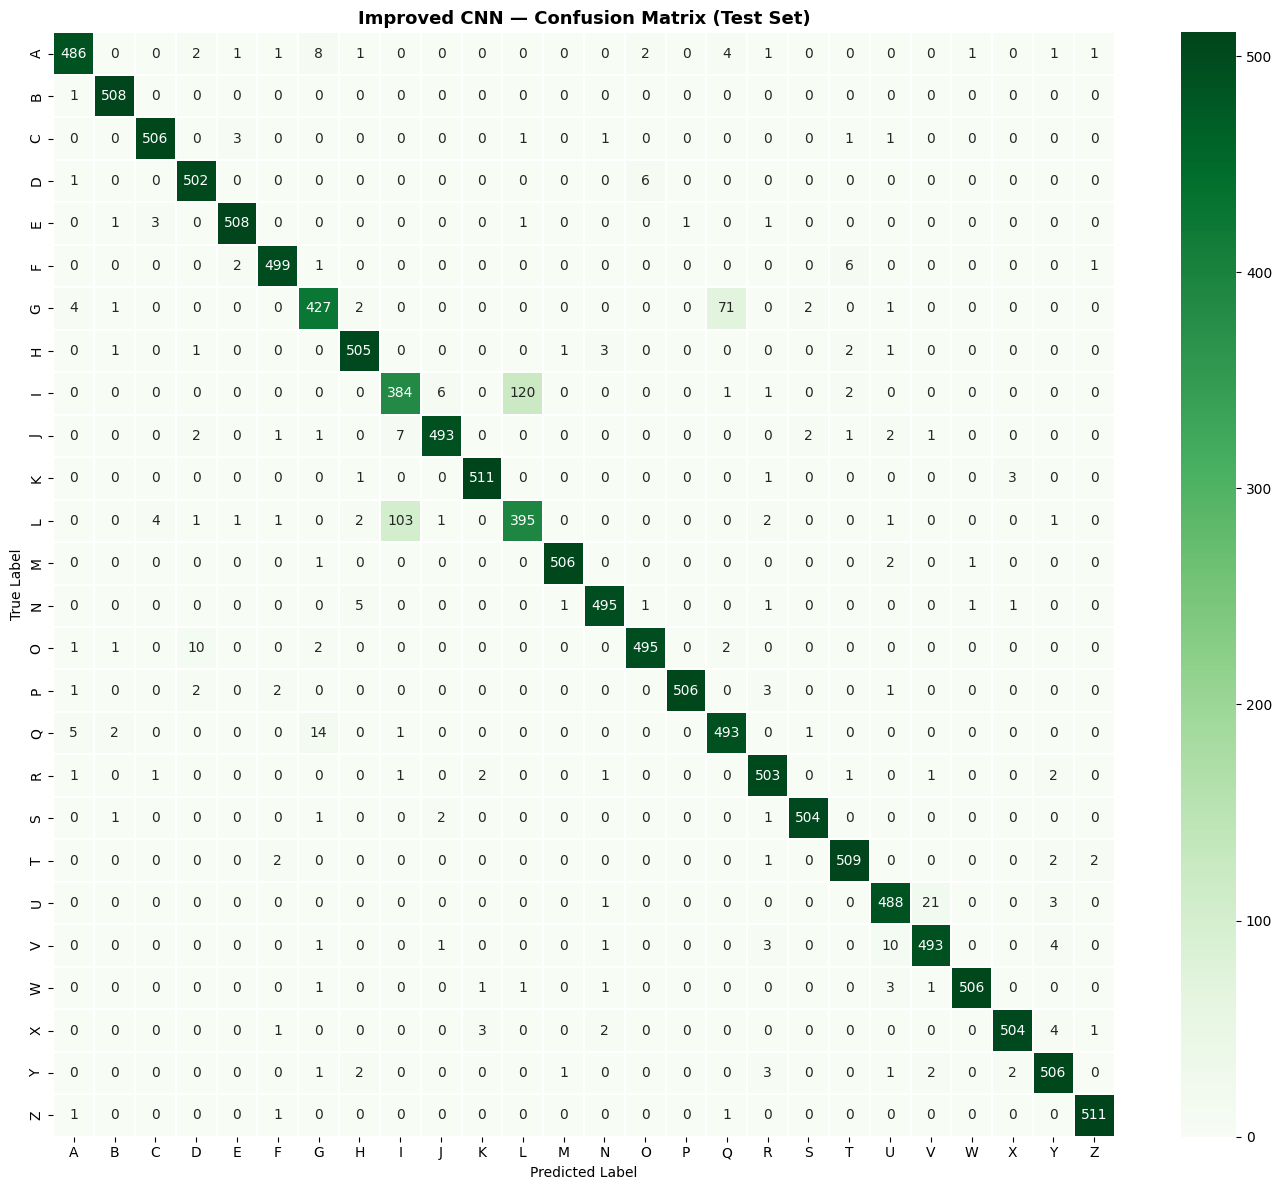


Classification Report:
              precision    recall  f1-score   support

           A       0.97      0.95      0.96       509
           B       0.99      1.00      0.99       509
           C       0.98      0.99      0.99       513
           D       0.97      0.99      0.98       509
           E       0.99      0.99      0.99       515
           F       0.98      0.98      0.98       509
           G       0.93      0.84      0.88       508
           H       0.97      0.98      0.98       514
           I       0.77      0.75      0.76       514
           J       0.98      0.97      0.97       510
           K       0.99      0.99      0.99       516
           L       0.76      0.77      0.77       512
           M       0.99      0.99      0.99       510
           N       0.98      0.98      0.98       505
           O       0.98      0.97      0.98       511
           P       1.00      0.98      0.99       515
           Q       0.86      0.96      0.91       516
   

In [39]:
# Confusion Matrix for improved model
y_pred_improved = np.argmax(improved_model.predict(X_test), axis=1)
cm_imp = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens',
            xticklabels=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'),
            yticklabels=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'),
            linewidths=0.3)
plt.title('Improved CNN — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_improved.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_improved, target_names=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')))

### 8.2 Results Summary

**Test Accuracy: 95.67% (+3.00% over baseline)**

| Metric | Baseline | Improved | Change |
|---|---|---|---|
| Test Accuracy | 92.67% | 95.67% | +3.00% ✅ |
| Test Loss | 0.2490 | 0.1230 | -0.126 ✅ |
| Error Rate | 7.33% | 4.33% | -3.00% ✅ |
| Overall F1 | 0.93 | 0.96 | +0.03 ✅ |
| Train/Val gap | ~4% | ~0.4% | Overfitting resolved ✅ |

**Most improved classes:**
- Q: 0.84 → 0.91 (+0.07) — deeper architecture better distinguishes curved shapes
- G: 0.82 → 0.88 (+0.06) — same reason

**Remaining limitations:**
- I (F1: 0.76) and L (F1: 0.77) remain the weakest classes — unchanged from baseline
- These letters share nearly identical vertical strokes in handwriting, making them inherently ambiguous even to human readers
- This is a data-level limitation that architecture improvements alone cannot fully resolve

**Augmentation conclusion:** The improved model with augmentation outperforms the baseline by +3.00%, confirming data augmentation is beneficial for this dataset.

--------------------------------------------------------------------------------------------------

## 9. Model Comparison and Analysis

In [40]:
# Side-by-side comparison
models_summary = {
    'Model': ['Baseline CNN', 'Improved CNN'],
    'Test Accuracy': [f'{test_acc*100:.2f}%', f'{test_acc_imp*100:.2f}%'],
    'Test Loss': [f'{test_loss:.4f}', f'{test_loss_imp:.4f}'],
    'Conv Blocks': [2, 3],
    'Batch Norm': ['No', 'Yes'],
    'Dropout': ['No', 'Yes'],
    'Augmentation': ['No', 'Yes']
}
pd.DataFrame(models_summary).set_index('Model')

,Test Accuracy,Test Loss,Conv Blocks,Batch Norm,Dropout,Augmentation
Model,,,,,,
Baseline CNN,92.67%,0.2490,2,No,No,No
Improved CNN,95.67%,0.1230,3,Yes,Yes,Yes


Number of misclassifications: 577 / 13320


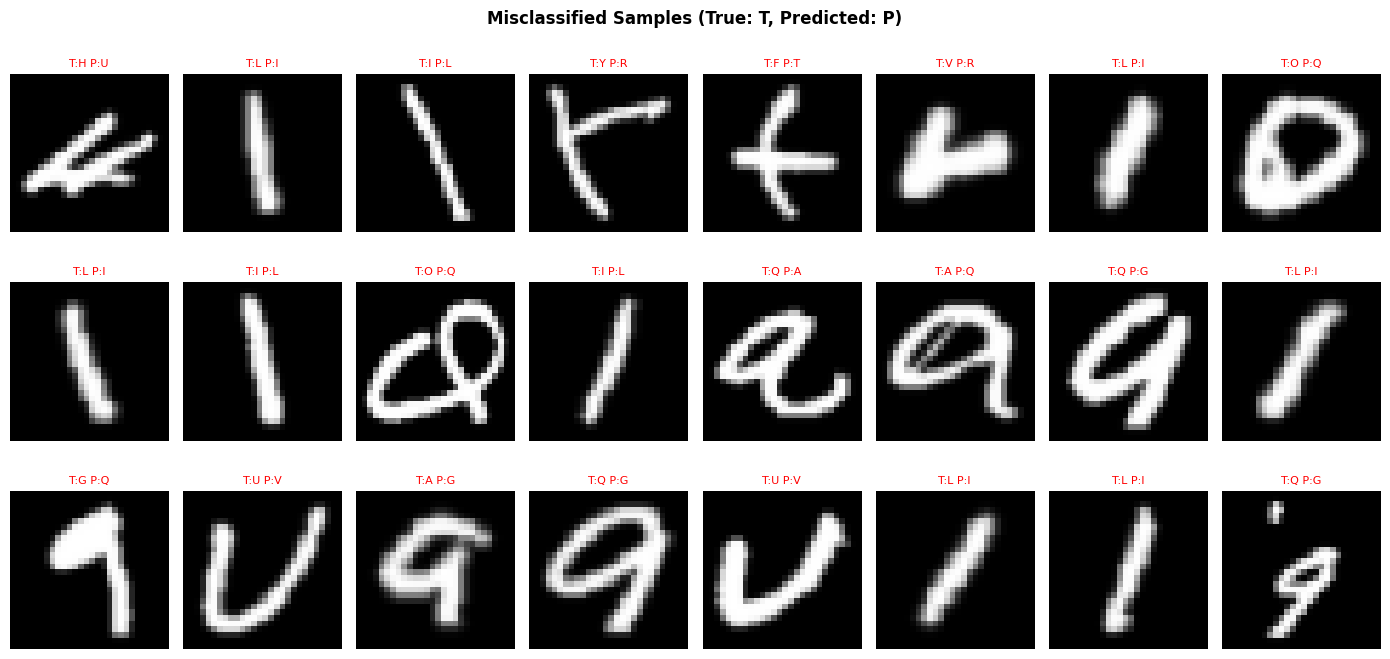

In [41]:
# Visualise some misclassified examples from improved model
wrong_idx = np.where(y_pred_improved != y_test)[0]
print(f'Number of misclassifications: {len(wrong_idx)} / {len(y_test)}')

fig, axes = plt.subplots(3, 8, figsize=(14, 7))
axes = axes.flatten()
for i, idx in enumerate(wrong_idx[:24]):
    axes[i].imshow(X_test[idx, :, :, 0], cmap='gray')
    true_l = chr(65 + y_test[idx])
    pred_l = chr(65 + y_pred_improved[idx])
    axes[i].set_title(f'T:{true_l} P:{pred_l}', fontsize=8,
                      color='red' if true_l != pred_l else 'green')
    axes[i].axis('off')

plt.suptitle('Misclassified Samples (True: T, Predicted: P)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified_samples.png', dpi=150)
plt.show()

### 9.1 Misclassification Analysis

Total misclassifications: **577 / 13,320 (4.33%)**

Visualising misclassified samples reveals clear patterns — all errors are visually explainable:
- **I/L/P**: Near-identical thin vertical strokes — even humans struggle to distinguish these in handwriting
- **Q/G/A**: All share circular or curved shapes
- **U/V**: Similar open-bottom shape
- **T/H**: Both contain horizontal strokes

**Conclusion:** The remaining errors are not random — they occur consistently on letters with genuine visual similarity. This suggests the model has learned the data well, and the remaining errors reflect fundamental ambiguity in handwritten letter shapes rather than model weakness.

--------------------------------------------------------------------------------------------------

## 10. Summary and Conclusions

### Overview
In this project, two Convolutional Neural Network (CNN) architectures were developed and evaluated for handwritten character classification using the provided dataset.

The **baseline CNN model**, consisting of two convolutional blocks without regularisation techniques, achieved a test accuracy of **92.67%** but exhibited noticeable overfitting, with an approximate train-validation gap of **4%**.

To address these limitations, an **improved CNN architecture** was designed with:
- an additional convolutional block,
- Batch Normalization,
- Dropout regularisation,
- data augmentation,
- and adaptive learning rate reduction using `ReduceLROnPlateau`.

The improved model achieved a significantly higher test accuracy of **95.67%**, while reducing the overfitting gap to approximately **0.4%**, indicating substantially better generalisation performance.

### Key Findings

1. **Model improvements significantly enhanced performance**  
   The combination of Batch Normalization, Dropout, and data augmentation improved classification accuracy by approximately **3.00%**, demonstrating the effectiveness of regularisation techniques in CNN training.

2. **Overfitting was effectively reduced**  
   Training and validation accuracy curves showed that the improved model generalised much better than the baseline model. The reduction of the train-validation gap from ~4% to ~0.4% confirmed that the added regularisation methods successfully mitigated overfitting.

3. **Batch Normalization improved training stability**  
   The inclusion of Batch Normalization resulted in smoother convergence behaviour and more stable loss curves throughout training, enabling faster and more consistent optimisation.

4. **Data augmentation improved generalisation capability**  
   Comparing the baseline and improved models demonstrated that augmentation helped the network become more robust to variations in handwritten characters, leading to better validation and test performance.

5. **Adaptive learning rate scheduling contributed to final accuracy gains**  
   The `ReduceLROnPlateau` callback was triggered during epochs 21 and 26, and both learning rate reductions were followed by measurable improvements in validation accuracy, indicating that adaptive learning rates helped the model converge more effectively.

6. **Certain classes remained challenging**  
   Despite the overall strong performance, visually similar handwritten characters such as **"I"** and **"L"** continued to produce lower F1-scores (~0.76). This limitation is likely caused by the inherent similarity in handwriting patterns rather than insufficient model complexity.

---

### Final Conclusion

Overall, the project successfully demonstrated how CNN architectures can be systematically improved through regularisation techniques, architectural enhancements, and training optimisation strategies. The final model achieved strong classification performance with minimal overfitting, showing that careful model design and evaluation are essential for developing reliable deep learning systems for image classification tasks.

---